In [12]:
%pip install tqdm
%pip install line_profiler
from concurrent.futures import ProcessPoolExecutor
# from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import Parameter, CircuitInstruction
from qiskit.circuit.library import QFT, PauliEvolutionGate
from qiskit.quantum_info import SparsePauliOp
from typing import Union, List, Tuple, Optional, Dict
import numpy as np
from qft_qpe_qdrift.algos import prepare_eigenstate_circuit

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## 1: Template circuits

In [13]:
# test Parameter 
H = SparsePauliOp.from_list([('Z', 0), ('X', 1), ('Y', 2)])
theta = Parameter('theta')
u_j = PauliEvolutionGate(H, theta)

u_j

Instruction(name='PauliEvolution', num_qubits=1, num_clbits=0, params=[Parameter(theta)])

Note: you may need to restart the kernel to use updated packages.


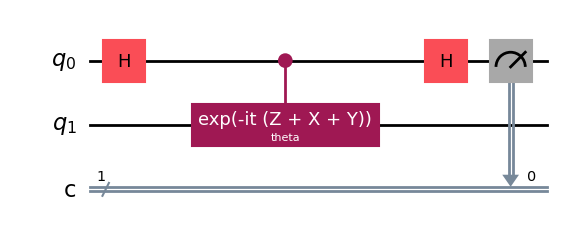

In [14]:
%pip install pylatexenc
qc = QuantumCircuit(2, 1)
qc.h(0)
c_u = u_j.control(1)
qc.append(c_u, [0, 1])
qc.h(0)
qc.measure(0, 0)

# visualize the circuit
qc.draw('mpl')

In [15]:
qc.parameters[0]

Parameter(theta)

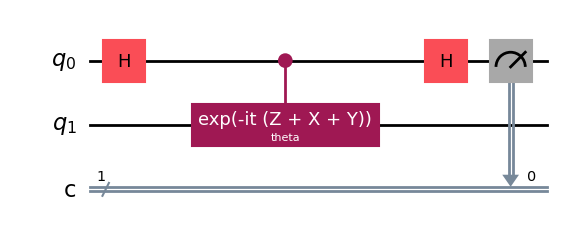

In [16]:
# bind the parameter
qc.assign_parameters({theta: np.pi / 4})
qc.draw('mpl')

## 2: "cached" $e^{iH_j\tau}$

aka direct access table, so we don't have to re-compute matrix exponentials every new qdrift sample

bless qiskit documentation: https://github.com/Qiskit/qiskit-tutorials/blob/master/tutorials/circuits_advanced/01_advanced_circuits.ipynb

In [17]:
def _make_pauli_gate_cache(ham: SparsePauliOp, placeholder_label: str) -> Dict[str, PauliEvolutionGate]:
    """Return one parameterised PauliEvolutionGate per Pauli label. This way we don't have to re-compute matrix exponentials every new qdrift sample"""
    tau = Parameter("tau")
    cache = {}
    for coeff, label in zip(ham.coeffs, ham.paulis.to_labels()):
        sign = np.sign(coeff).item() or 1.0
        cache[label] = PauliEvolutionGate(SparsePauliOp([label], [sign]), tau)
    # add a dummy gate for the identity
    num_qubits = ham.num_qubits
    cache[placeholder_label] = PauliEvolutionGate(SparsePauliOp.from_list([('I' * num_qubits, 1.0)]), tau)
    return cache

H = SparsePauliOp.from_list([('ZZ', 0.5), ('XZ', 1), ('YZ', 2)])
pauli_gate_cache = _make_pauli_gate_cache(H, 'dummy')
pauli_gate_cache

{'ZZ': Instruction(name='PauliEvolution', num_qubits=2, num_clbits=0, params=[Parameter(tau)]),
 'XZ': Instruction(name='PauliEvolution', num_qubits=2, num_clbits=0, params=[Parameter(tau)]),
 'YZ': Instruction(name='PauliEvolution', num_qubits=2, num_clbits=0, params=[Parameter(tau)]),
 'dummy': Instruction(name='PauliEvolution', num_qubits=2, num_clbits=0, params=[Parameter(tau)])}

## 3: combining both: direct access table of parametrized operations

In [18]:

def _template_circuit(n_anc: int, n_sys: int, placeholder_label: str, eigenvalue_circuit: QuantumCircuit, pauli_cache: Dict[str, PauliEvolutionGate]) -> QuantumCircuit:
    """
    Static scaffold that already contains *all*  controlled placeholders:
    layer k gets 2**k placeholders so the stochastic product can be realised.
    """
    qc = QuantumCircuit(n_anc + n_sys, n_anc, name="qDRIFT-QPE")
    qc.append(eigenvalue_circuit, range(n_anc, n_anc+n_sys))
    qc.h(range(n_anc))

    # --- allocate the necessary number of placeholders -----------------
    ctrl_gates = []
    for k in range(n_anc):
        for _ in range(2**k):
            dummy = pauli_cache[placeholder_label].control(1)     # any label is fine
            # explicitly name the placeholder
            dummy.name = f"ctrl-evolution-{k}-{placeholder_label}"
            ctrl_gates.append( (k, dummy) )

    # add them in the *same* order every time  →  topology  is fixed
    sys = range(n_anc, n_anc+n_sys)
    for k, dummy in ctrl_gates:
        qc.append(dummy, [k, *sys])

    qc.append(QFT(n_anc, inverse=True), range(n_anc))
    qc.measure(range(n_anc), range(n_anc))
    return qc

/var/folders/t7/fs05qlp5227_wpg4jmr00_mc0000gn/T/ipykernel_72570/1533783430.py:24: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(n_anc, inverse=True), range(n_anc))


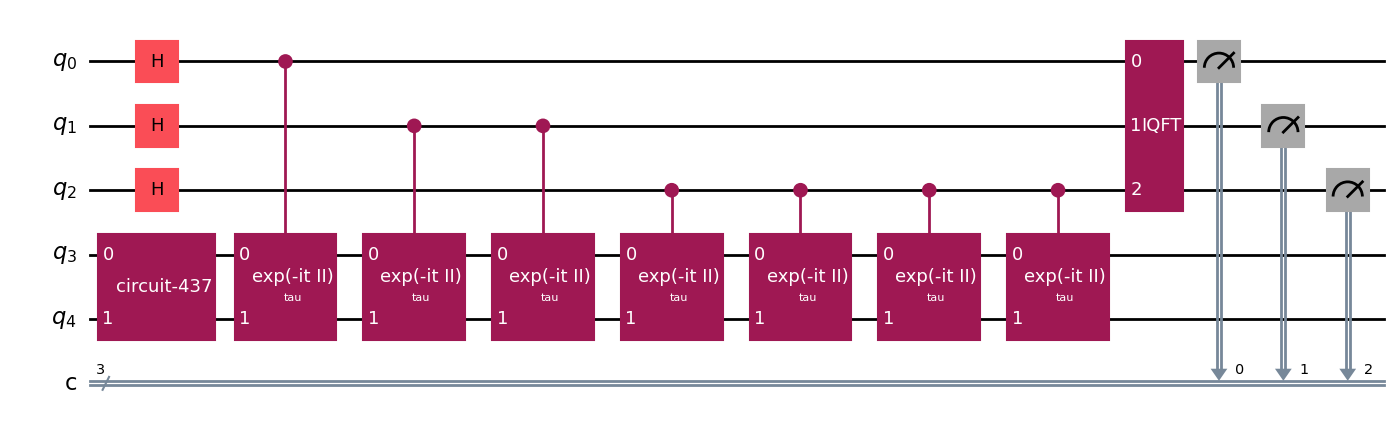

In [19]:
N_SYSTEM = 2
H = SparsePauliOp.from_list([('ZZ', 0.5), ('XZ', 1), ('YZ', 2)])
PAULI_CACHE = _make_pauli_gate_cache(H, 'dummy')
eigenvalues, eigenvectors = np.linalg.eigh(H.to_matrix())
GROUND_STATE = eigenvectors[:, np.argmin(eigenvalues)]
EIG_CIRC = prepare_eigenstate_circuit(GROUND_STATE)
PAULI_LABELS = H.paulis.to_labels()

qc = _template_circuit(
    n_anc=3,
    n_sys=N_SYSTEM,
    placeholder_label='dummy',
    eigenvalue_circuit=EIG_CIRC,
    pauli_cache=PAULI_CACHE
)
qc.draw('mpl')

In [20]:
qc.parameters

ParameterView([Parameter(tau)])

## What lives in the template circuit?

- registers, QFT, inverse QFT, eigenstate preparation;

- One controlled gate for each $\sum_{k=0}^{m - 1} 2^m - 1$ qDRIFT factors

The placeholders carry a dummy `PauliEvolutionGate` whose angle is the symbolic `Parameter('tau')`.


`QuantumCircuit.data` is simply a Python list of 3-tuples

`(operation,  [qubit_0, qubit_1, …],  [clbit_0, …])`

Therefore overwriting tuple[0] replaces the gate in place without touching the compiled wiring.


In [21]:
from typing import List
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit.library import PauliEvolutionGate

# ---- global objects prepared elsewhere ----------------------------------
TEMPLATE_CACHE: Dict[Tuple[int, float], QuantumCircuit] = {}  # cache for templates


def build_qdrift_trajectory(
        n_anc: int,
        total_time: float,
        rng: np.random.Generator,
        pmf: np.ndarray,
        n_qdrift_segments: Optional[int],
        placeholder_label: str
) -> QuantumCircuit:
    """
    Return ONE qDRIFT–QPE circuit whose unitary equals the stochastic product
    required by the algorithm in §1 (N = 2^m-1 samples, each drawn i.i.d.).

    Parameters
    ----------
    n_anc : int
        Number of ancilla / counting qubits  (m in the pseudo-code).
    total_time : float
        Physical simulation time  t.
    rng : np.random.Generator
        Local random-number generator   (allows thread-safety).
    pmf : np.ndarray
        Probability mass function for the Pauli words  (length = 2^m-1).
        Must sum to 1.0.
    n_qdrift_segments : Optional[int]
        Number of segments in the qDRIFT trajectory.
        If None, defaults to 1.

    Returns
    -------
    QuantumCircuit
        Fully-bound and ready-to-simulate trajectory.
    """

    # 1 ───── copy static scaffold ────────────────────────────────────────
    template_qc = TEMPLATE_CACHE[(n_anc, total_time)].copy()      # shallow copy keeps wiring

    # 2 ───── draw the Pauli words  (independent for every placeholder) ──
    n_placeholders = 2**n_anc - 1
    print(f"Generating {n_placeholders} placeholders for {n_anc} ancilla qubits.\nDrawing from pmf: {pmf} \nHamiltonian: {H}.\nLabels: {PAULI_LABELS}")
    words: List[str] = rng.choice(PAULI_LABELS, p=pmf, size=n_placeholders)
    print(f"Drawn words: {words}")

    new_data = []
    word_iterator = iter(words)
    for instruction in template_qc.data:
        if placeholder_label in instruction.operation.name:
            chosen_word = next(word_iterator)
            new_gate = PAULI_CACHE[chosen_word].control(1)
            new_instruction = CircuitInstruction(new_gate, instruction.qubits, instruction.clbits)
            new_data.append(new_instruction)
        else:
            new_data.append(instruction)

    template_qc.data = new_data
    print(f"New circuit data: {template_qc.data}")
    
    lam = np.sum(np.abs(H.coeffs))
    tau_val = (lam * total_time) / n_qdrift_segments if n_qdrift_segments > 0 else 0
    tau_param = PAULI_CACHE[placeholder_label].params[0]
    
    qdrift_trajectory = template_qc.assign_parameters({tau_param: tau_val})

    return qdrift_trajectory

## Why it is fast and memory-safe


compilation of the shape happens once per n_anc;
replacing inst.operation never allocates a $2^n \times 2^n$ matrix;
bind_parameters touches only the float angle ‒ no DAG rebuild;
the circuit object itself is a few 100 kB, independent of system size.

/var/folders/t7/fs05qlp5227_wpg4jmr00_mc0000gn/T/ipykernel_72570/1533783430.py:24: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(n_anc, inverse=True), range(n_anc))


{'ZZ': Instruction(name='PauliEvolution', num_qubits=2, num_clbits=0, params=[Parameter(tau)]), 'XZ': Instruction(name='PauliEvolution', num_qubits=2, num_clbits=0, params=[Parameter(tau)]), 'YZ': Instruction(name='PauliEvolution', num_qubits=2, num_clbits=0, params=[Parameter(tau)]), 'dummy': Instruction(name='PauliEvolution', num_qubits=2, num_clbits=0, params=[Parameter(tau)])}
Generating 15 placeholders for 4 ancilla qubits.
Drawing from pmf: [0.14285714 0.28571429 0.57142857] 
Hamiltonian: SparsePauliOp(['ZZ', 'XZ', 'YZ'],
              coeffs=[0.5+0.j, 1. +0.j, 2. +0.j]).
Labels: ['ZZ', 'XZ', 'YZ']
Drawn words: ['ZZ' 'XZ' 'YZ' 'YZ' 'XZ' 'XZ' 'XZ' 'YZ' 'YZ' 'YZ' 'ZZ' 'YZ' 'YZ' 'YZ'
 'YZ']
New circuit data: [CircuitInstruction(operation=Instruction(name='circuit-475', num_qubits=2, num_clbits=0, params=[]), qubits=(<Qubit register=(6, "q"), index=4>, <Qubit register=(6, "q"), index=5>), clbits=()), CircuitInstruction(operation=Instruction(name='h', num_qubits=1, num_clbits=0, param

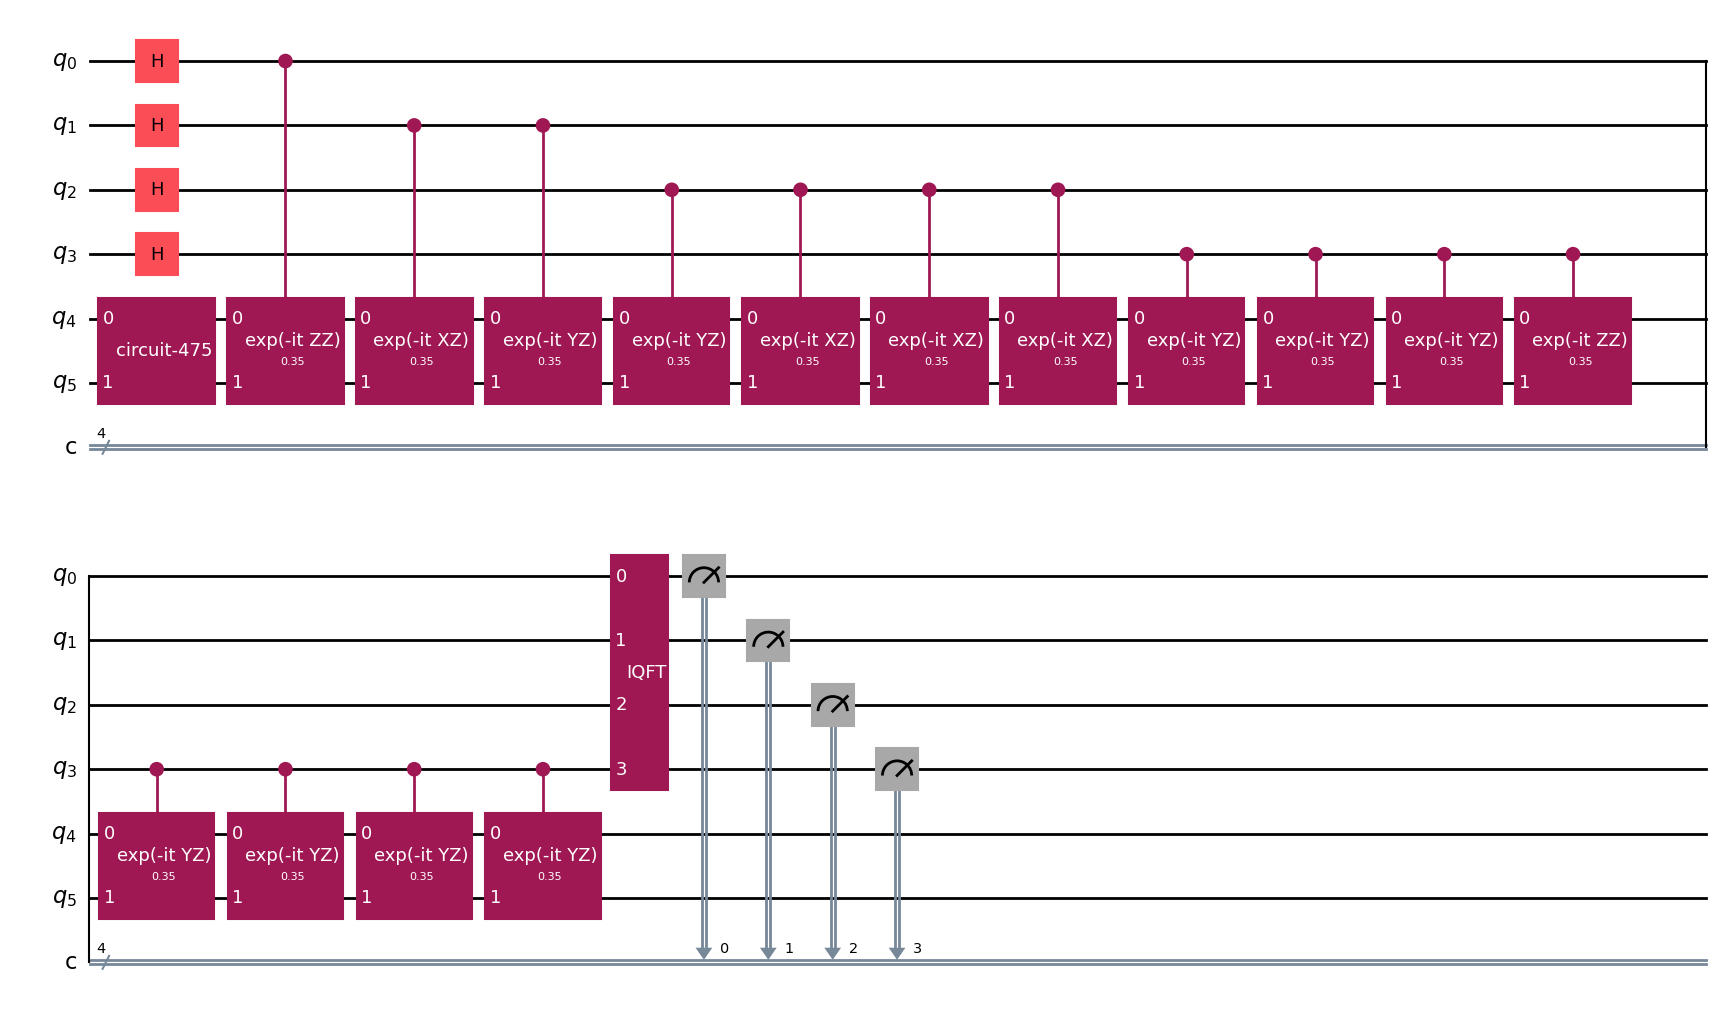

In [22]:
PLACEHOLDER_LABEL = 'dummy'
PAULI_LABELS = H.paulis.to_labels()
GROUND_STATE = eigenvectors[:, np.argmin(eigenvalues)]
EIG_CIRC = prepare_eigenstate_circuit(GROUND_STATE)
PAULI_CACHE = _make_pauli_gate_cache(H, PLACEHOLDER_LABEL)
TEMPLATE_CACHE: Dict[Tuple[int, float], QuantumCircuit] = {(n_anc, tot_time): _template_circuit(n_anc, N_SYSTEM, PLACEHOLDER_LABEL, EIG_CIRC, PAULI_CACHE) for n_anc in range(4, 6) for tot_time in [0.1]}
N_SYSTEM = 2
H = SparsePauliOp.from_list([('ZZ', 0.5), ('XZ', 1), ('YZ', 2)])

print(PAULI_CACHE)
eigenvalues, eigenvectors = np.linalg.eigh(H.to_matrix())

PMF = np.abs(H.coeffs) / np.abs(H.coeffs).sum()             # np.ndarray with qDRIFT probabilities |h_j| / λ


qdrift_trajectory = build_qdrift_trajectory(n_anc=4, total_time=0.1, rng=np.random.default_rng(), pmf=PMF, n_qdrift_segments=1, placeholder_label=PLACEHOLDER_LABEL)
qdrift_trajectory.draw('mpl')

Note that there is a differrence between the total number of iid qdrift samples per layer in the QPE circuit and the number of "qdrift segments". the former is always 2^{k-1} for layer k - as prescribed by the qpe protocol. The latter is always 1. Explain this is the case. Note that this qpe+qdrift implementation is fundamentally different from the one described in the original qDRIFT paper "A random compiler for fast Hamiltonian simulation".